In [1]:
import numpy as np
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from ClassA import RFI_MakeEnvelopeDataClassA
from Estimadores import *
from matplotlib.gridspec import GridSpec

mpl.rc('font',family = 'Times New Roman')

In [2]:
#-------------------------------------------
#----------------- Parámetros --------------
r = np.array([0.01, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 1, 2, 3, 5])
A = 0.005
Sigma_G_sq = 0.001
#-------------------------------------------
#-------------------------------------------
veces = 50
N = 5000
#-----------------------------------
#-----------------------------------
n = np.size(r)
D1a2 = 10*np.log10(1+1/(A*r))
print (D1a2)

[43.0105171  33.01247089 30.00434077 28.24559695 26.03144373 24.57449332
 23.99673721 23.03196057 20.04321374 18.30374783 16.12783857]


In [3]:
# Inicializacion del vector A_ini
vec_A_ini                = np.zeros((veces,n))
vec_r_ini                = np.zeros((veces,n))
vec_Sigmag2_ini          = np.zeros((veces,n))
vec_densidad             = np.zeros((veces,n))
vec_valor_medio          = np.zeros((veces,n))
vec_valor_medio_gauss    = np.zeros((veces,n))
vec_valor_medio_no_gauss = np.zeros((veces,n))
vec_valor_medio_log      = np.zeros((veces,n))

for j in range(len(r)):
    #print (j)
    for i in range(veces):
        #print (i)
        env_data_Norm,env_data_DesNorm = RFI_MakeEnvelopeDataClassA(A,r[j],10,N,Sigma_G_sq)

        # Estimador inicial
        A_ini,Sigmag2_ini,r_ini,densidad,valor_medio,valor_medio_gauss,valor_medio_no_gauss,valor_medio_log = est_inicial_densidad(env_data_DesNorm)
        vec_A_ini[i,j]                = A_ini
        vec_Sigmag2_ini[i,j]          = Sigmag2_ini
        vec_r_ini[i,j]                = r_ini
        vec_densidad[i,j]             = densidad
        vec_valor_medio[i,j]          = valor_medio
        vec_valor_medio_gauss[i,j]    = valor_medio_gauss
        vec_valor_medio_no_gauss[i,j] = valor_medio_no_gauss
        vec_valor_medio_log[i,j]      = valor_medio_log

print ('FIN')

FIN


In [5]:
densidad_prom = np.sum(vec_densidad, axis=0)/veces
valor_medio_prom = np.sum(vec_valor_medio, axis = 0)/veces
valor_medio_gauss_prom = np.sum(vec_valor_medio_gauss, axis = 0)/veces
valor_medio_no_gauss_prom = np.sum(vec_valor_medio_no_gauss, axis = 0)/veces
valor_valor_medio_log = np.sum(vec_valor_medio_log, axis = 0)/veces
print ('Densidad:',densidad_prom)
print ('Potencia promedio:',valor_medio_prom)
print ('Potencia promedio log:',10*np.log10(valor_medio_prom))
print ('Potencia promedio vec log:',valor_valor_medio_log)
print ('Potencia promedio gaussiana:',valor_medio_gauss_prom)
print ('Potencia promedio no gaussiana:',valor_medio_no_gauss_prom)

# ----------- Cálculo del error cuadrático medio en la est. de A -------------------
mse_est_simple  = np.sum((vec_A_ini - A)**2,axis=0)/veces

# ----------- Cálculo del error cuadrático medio en la est. de r -------------------
mse_est_simple_r = np.sum((vec_r_ini - r)**2,axis=0)/veces

# ----------- Cálculo del error cuadrático medio en la est. de r -------------------
mse_est_simple_sigma = np.sum((vec_Sigmag2_ini - Sigma_G_sq)**2,axis=0)/veces

print ('MSE de A:', mse_est_simple)
print ('MSE de r:', mse_est_simple_r)
print ('MSE de Sigma_G_sq:', mse_est_simple_sigma)

Densidad: [0.568556 0.56962  0.572176 0.579292 0.594032 0.604364 0.603036 0.605996
 0.605988 0.602284 0.600364]
Potencia promedio: [0.09747738 0.01077523 0.00582287 0.00431455 0.00305349 0.00235841
 0.00225095 0.00205174 0.00149889 0.00132331 0.00120599]
Potencia promedio log: [-10.11096152 -19.6757328  -22.34862632 -23.65064541 -25.15203144
 -26.27381104 -26.47634793 -26.87876942 -28.24228976 -28.78336867
 -29.18655679]
Potencia promedio vec log: [-32.29683817 -32.36546465 -32.34715583 -32.37285718 -32.39539928
 -32.39849878 -32.37439533 -32.37616782 -32.41435641 -32.419441
 -32.40996607]
Potencia promedio gaussiana: [-32.50692497 -32.53675964 -32.54586111 -32.70187839 -32.98974819
 -33.36034251 -33.41609571 -33.59805447 -34.333156   -34.64995852
 -34.89066351]
Potencia promedio no gaussiana: [ 10.58859147  -0.90606868 -10.35492721 -17.26927046 -22.17407105
 -24.00467394 -24.23131102 -24.72641747 -26.00244807 -26.4185366
 -26.72977557]
MSE de A: [8.68000000e-07 2.71280000e-06 5.333920

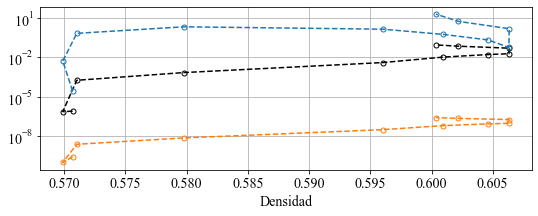

In [8]:
# -------------- FIGURAS -------------------------------------------------------------
# ------------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(8.8, 6.6))
gs0 = GridSpec(nrows=2, ncols=2)

ax0 = fig1.add_subplot(gs0[0, :])
#ax0.set_xscale('log')
ax0.set_yscale('log')
ax0.set_xlabel('Densidad',fontsize = 14)
ax0.plot(densidad_prom, mse_est_simple, '--o', fillstyle = 'none', markersize = 5, color = 'black', label = 'MSE A')
ax0.plot(densidad_prom, mse_est_simple_r, '--o', fillstyle = 'none', markersize = 5, color = 'tab:blue', label = 'MSE $\Gamma$')
ax0.plot(densidad_prom, mse_est_simple_sigma, '--o', fillstyle = 'none', markersize = 5, color = 'tab:orange', label = 'MSE $\sigma_{G}^{2}$')
ax0.grid(True)
ax0.tick_params(axis="x", labelsize=14)
ax0.tick_params(axis="y", labelsize=14)

plt.show()